Final annotated figure successfully saved to Figure_1g.pdf


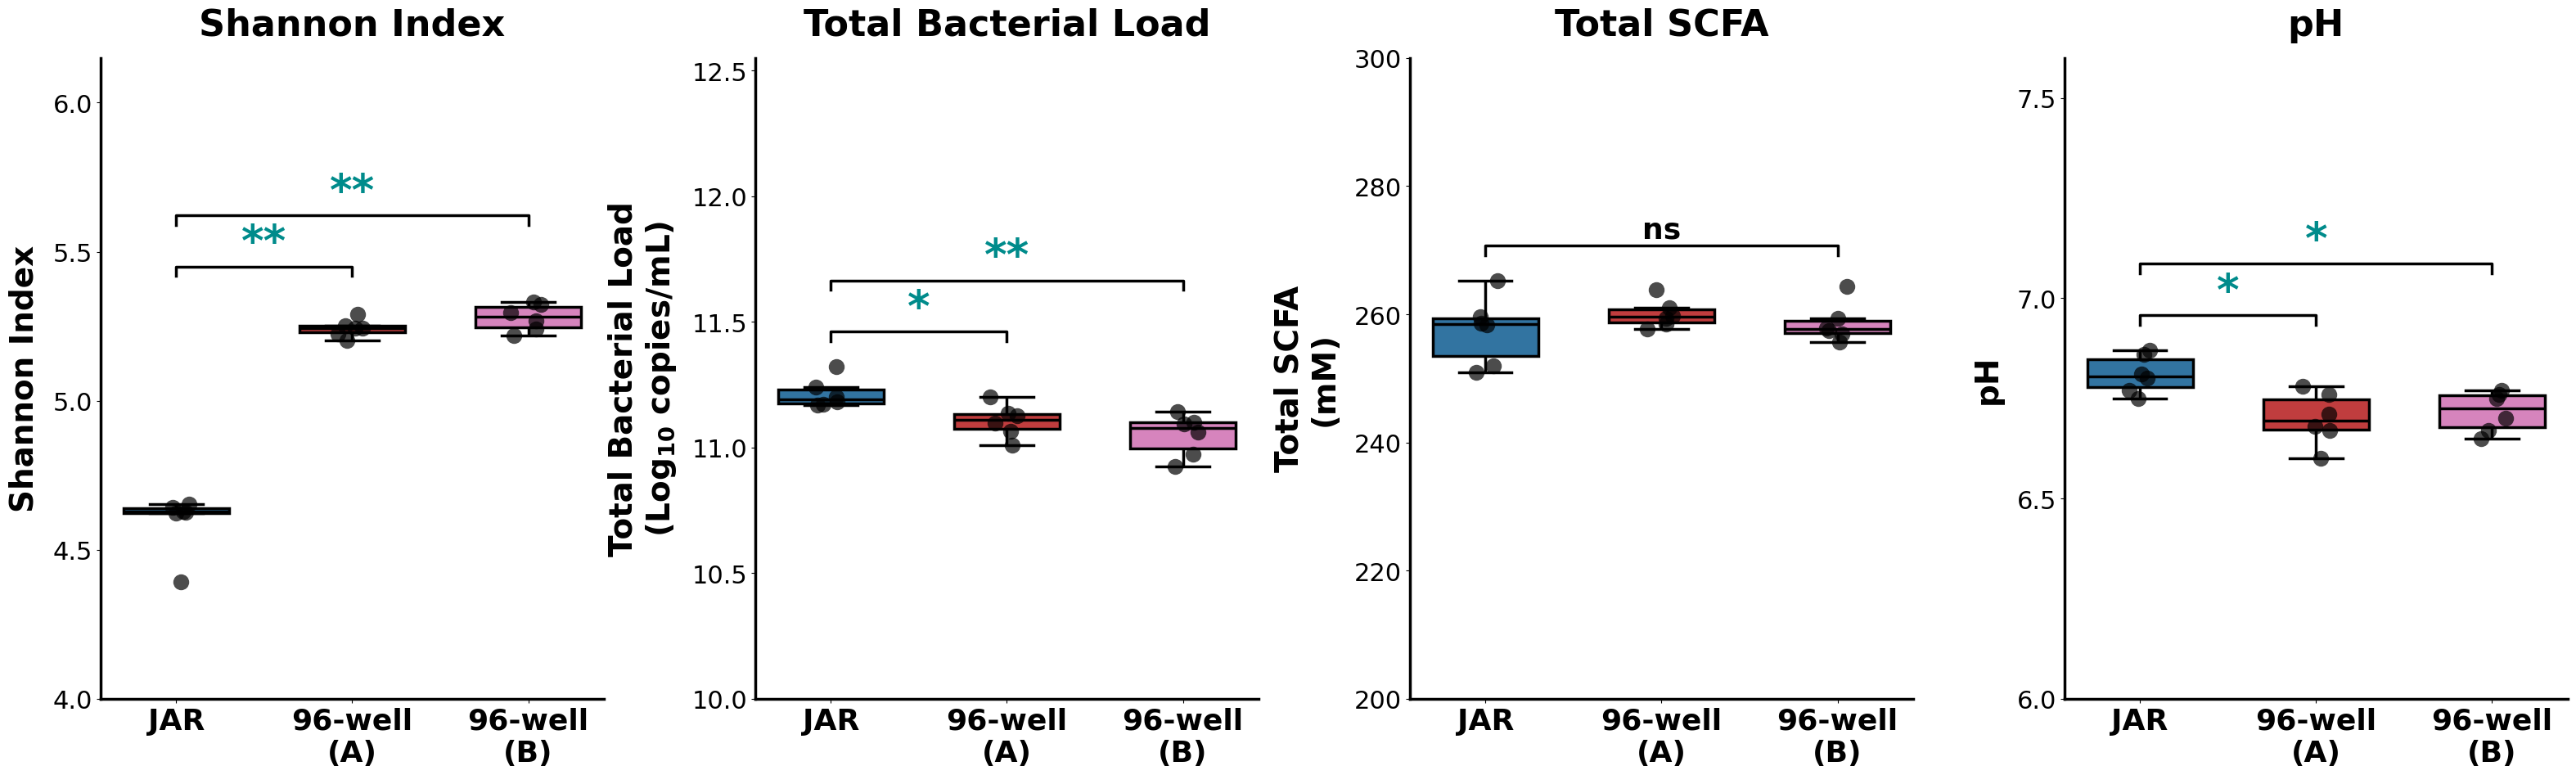

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import warnings

warnings.filterwarnings('ignore')

# =============================================================================
# Global Plotting Configuration (Strict Nature Standards)
# =============================================================================
plt.rcParams.update({
    'font.size': 24,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'sans-serif'],
    'pdf.fonttype': 42,
    'axes.linewidth': 2.5,
    'mathtext.default': 'regular'
})

# Universal Settings for Significance Markers
STAR_COLOR = '#008B8B'  # Dark Turquoise
STAR_SIZE = 38

def annotate_bracket(ax, x1, x2, y_base, h, text, is_star=False):
    """Draws a strict, professional statistical bracket."""
    ax.plot([x1, x1, x2, x2], [y_base, y_base+h, y_base+h, y_base], lw=2.5, c='k')
    if is_star:
        ax.text((x1+x2)*0.5, y_base+h + h*0.2, text, ha='center', va='bottom',
                color=STAR_COLOR, fontsize=STAR_SIZE, fontweight='bold')
    else:
        ax.text((x1+x2)*0.5, y_base+h + h*0.2, text, ha='center', va='bottom',
                color='k', fontsize=26, fontweight='bold')

# =============================================================================
# 1. Process Shannon Raw Data
# =============================================================================
df_shannon_raw = pd.read_csv('(1g)_Shannon.csv')
numeric_cols = [c for c in df_shannon_raw.columns if c.startswith('depth')]
df_shannon_raw['Value'] = df_shannon_raw[numeric_cols].max(axis=1)

def categorize_groups(cluster):
    if '72h' not in str(cluster): return None
    if 'GAM' in str(cluster): return 'JAR'
    if 'P1' in str(cluster): return '96well-A'
    if 'P2' in str(cluster): return '96well-B'
    return None

df_shannon_raw = df_shannon_raw.copy()
df_shannon_raw['Group'] = df_shannon_raw['Cluster'].apply(categorize_groups)
df_shannon_72h = df_shannon_raw.dropna(subset=['Group'])[['Group', 'Value']]

# =============================================================================
# 2. Process Validation Datasets
# =============================================================================
data_files = {
    'Shannon Index': df_shannon_72h,
    'Total Bacterial Load\n(Log$_{10}$ copies/mL)': '1g_Total_Bacteria.csv',
    'Total SCFA\n(mM)': '1g_Total_SCFA.csv',
    'pH': '1g_pH.csv'
}

all_data = {}
for label, data in data_files.items():
    if isinstance(data, str):
        df_temp = pd.read_csv(data)
        # Forward fill the group column (JAR, 96well-A, 96well-B)
        df_temp.iloc[:, 0] = df_temp.iloc[:, 0].ffill()

        # Clean up naming
        mapping = {'JAR': 'JAR', '96well-A': '96well-A', '96well-B': '96well-B', '96-well-A': '96well-A', '96-well-B': '96well-B'}
        df_temp.iloc[:, 0] = df_temp.iloc[:, 0].map(mapping)
        df_temp = df_temp.dropna(subset=[df_temp.columns[0]])

        df_temp = df_temp.iloc[:, [0, 1]]
        df_temp.columns = ['Group', 'Value']
        all_data[label] = df_temp
    else:
        all_data[label] = data

# =============================================================================
# 3. Y-axis Config Definitions (FIX: Lowered upper limits for compactness)
# =============================================================================
y_configs = {
    'Shannon Index': {
        'ylim': (4.0, 6.15),  # Lowered from 6.4
        'yticks': np.arange(4.0, 6.1, 0.5),
        'precision': 1
    },
    'Total Bacterial Load\n(Log$_{10}$ copies/mL)': {
        'ylim': (10.0, 12.55), # Lowered from 12.8
        'yticks': np.arange(10.0, 12.6, 0.5),
        'precision': 1
    },
    'Total SCFA\n(mM)': {
        'ylim': (200, 300),    # Lowered from 310
        'yticks': np.arange(200, 301, 20),
        'precision': 0
    },
    'pH': {
        'ylim': (6.0, 7.6),    # Lowered from 7.8
        'yticks': np.arange(6.0, 7.6, 0.5),
        'precision': 1
    }
}

# =============================================================================
# 4. Figure Generation
# =============================================================================
fig, axes = plt.subplots(1, 4, figsize=(32, 10))
group_order = ['JAR', '96well-A', '96well-B']

# Color Palette
palette = {'JAR': '#1f77b4', '96well-A': '#d62728', '96well-B': '#e377c2'}

plot_order = [
    'Shannon Index',
    'Total Bacterial Load\n(Log$_{10}$ copies/mL)',
    'Total SCFA\n(mM)',
    'pH'
]

for i, title in enumerate(plot_order):
    ax = axes[i]
    df_plot = all_data[title]

    # Boxplot
    sns.boxplot(x='Group', y='Value', data=df_plot, order=group_order,
                palette=palette, width=0.6, ax=ax, showfliers=False, linewidth=2.5, boxprops=dict(alpha=1.0))

    for patch in ax.patches: patch.set_edgecolor('black')
    for line in ax.lines: line.set_color('black')

    # Stripplot
    sns.stripplot(x='Group', y='Value', data=df_plot, order=group_order,
                  color='black', alpha=0.7, size=14, jitter=True, ax=ax)

    # Labeling (Slightly reduced pad to bring title and labels closer)
    ax.set_title(title.split('\n')[0], fontsize=32, pad=20, fontweight='bold')
    ax.set_ylabel(title, fontsize=28, fontweight='bold', labelpad=12)
    ax.set_xlabel("")
    ax.set_xticklabels(['JAR', '96-well\n(A)', '96-well\n(B)'], fontsize=26, fontweight='bold')

    # Apply limits and regular weight Y-axis numbers
    conf = y_configs[title]
    ax.set_ylim(conf['ylim'])
    ax.set_yticks(conf['yticks'])
    precision = conf['precision']

    labels_y = ax.set_yticklabels([f"{y:.{precision}f}" for y in conf['yticks']], fontsize=22)
    for label in labels_y:
        label.set_fontweight('normal')

    # =========================================================================
    # 5. Statistical Annotation (Mann-Whitney U, with Tiered Brackets)
    # =========================================================================
    jar_data = df_plot[df_plot['Group'] == 'JAR']['Value'].dropna().values
    a_data = df_plot[df_plot['Group'] == '96well-A']['Value'].dropna().values
    b_data = df_plot[df_plot['Group'] == '96well-B']['Value'].dropna().values

    stat_a, p_a = mannwhitneyu(jar_data, a_data, alternative='two-sided')
    stat_b, p_b = mannwhitneyu(jar_data, b_data, alternative='two-sided')

    def p_to_stars(p):
        if p < 0.001: return '***'
        if p < 0.01: return '**'
        if p < 0.05: return '*'
        return 'ns'

    # Calculate bracket positions dynamically based on new compact data scale
    y_max = df_plot['Value'].max()
    y_range = conf['ylim'][1] - conf['ylim'][0]
    bracket_h = y_range * 0.015  # Slightly shorter bracket legs

    # Tier 1: Adjacent comparison (JAR vs 96-well A)
    y_tier1 = y_max + y_range * 0.04
    # Tier 2: Spanning comparison (JAR vs 96-well B)
    y_tier2 = y_max + y_range * 0.12

    # Total SCFA receives 'ns' annotation spanning across
    if 'Total SCFA' in title:
        annotate_bracket(ax, 0, 2, y_tier1, bracket_h, 'ns', is_star=False)
    else:
        if p_a < 0.05:
            annotate_bracket(ax, 0, 1, y_tier1, bracket_h, p_to_stars(p_a), is_star=True)
        if p_b < 0.05:
            annotate_bracket(ax, 0, 2, y_tier2, bracket_h, p_to_stars(p_b), is_star=True)

sns.despine()
plt.tight_layout()
plt.subplots_adjust(wspace=0.3)

# Save final high-resolution PDF
output_file = "Figure_1g.pdf"
plt.savefig(output_file, dpi=600, transparent=True, bbox_inches='tight', pad_inches=0.2)
print(f"Final annotated figure successfully saved to {output_file}")